# Trees & Ensembles: Decision Trees & Random Forests

## 1. Theoretical Foundation

In the previous notebooks, we explored models that required rigorous mathematical assumptions. Logistic Regression needed linear boundaries. Naive Bayes assumed features were completely independent. Support Vector Machines projected data into higher-dimensional geometry. 

But human decision-making rarely works like a complex geometric equation. When a doctor diagnoses a patient, they don't calculate a 30-dimensional hyperplane. Instead, they ask a series of simple *Yes/No* questions:
* "Does the patient have a fever?" (Yes $\rightarrow$ Next question / No $\rightarrow$ Healthy)
* "Is the fever over 39°C?" 

Welcome to **Decision Trees**, the absolute most intuitive algorithm in Machine Learning. It works by recursively partitioning the dataset into smaller and smaller boxes based on simple rules. 

### 1.1 Decision Trees (CART/C4.5)
A Decision Tree builds a flowchart. At every node, it looks at all available features and asks: *"Which question can I ask right now that will perfectly split my data into the purest possible groups?"* 

It measures this "purity" using math like **Gini Impurity** or **Entropy (Information Gain)**. If a question splits a mixed bag of Apples and Oranges into one bucket of 100% Apples and another of 100% Oranges, the Gini impurity drops to zero. That question is chosen.

**The Problem:** Trees are incredibly greedy. If you let them grow infinitely deep, they will ask enough hyper-specific questions to perfectly memorize the entire training dataset (e.g., *"Is the passenger female? AND is she in 3rd class? AND is her ticket number #321? AND is she 24.5 years old? $\rightarrow$ Survived!"*). This is massive overfitting.

### 1.2 Ensembles: The Wisdom of Crowds
If one tree memorizes noise, what if we plant a forest? 

**Random Forest (Bagging):**
Instead of relying on one deep, overfitted tree, we build hundreds of shallower trees. But here is the trick: we cannot give them all the same data, or they will all ask the same questions and make the exact same mistakes. 
1. We bootstrap the data (give each tree a random subset of rows).
2. We bootstrap the features (force each tree to only consider a random subset of columns at each split). 
When predicting, the trees vote. The errors average out, variance drops massively, and accuracy skyrockets.

**Extra Trees (Extremely Randomized Trees):**
Goes one step further than Random Forest. Instead of calculating the *optimal* split for a feature, it picks a *completely random* split threshold. This makes the model train blazingly fast and reduces variance even further, though it might increase bias slightly.

### 1.3 The Roadmap
1. **Intuition & Data:** We will use the iconic **Titanic** dataset. It requires heavy preprocessing (handling missing values, categories, and socio-economic feature interactions like "Women and Children first").
2. **Scratch:** We will build a recursive Decision Tree from scratch using pure NumPy and Gini Impurity logic to see exactly how an algorithm "learns" to ask questions.
3. **Pro:** We will deploy Scikit-Learn's Random Forest and Extra Trees to see how ensembles shatter the limitations of single trees.
4. **Visuals:** We will plot feature importance and visualize the actual tree splits.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Standard ATLAS styling
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 15

print("Libraries imported and styling set.")

Libraries imported and styling set.


## 2. Data Preparation: The Titanic Disaster

Tree-based models are unique: they **do not require feature scaling** (like StandardScaler). Why? Because asking "Is Age > 30?" works identical mathematically whether Age is stored as `30` or transformed to `0.54`. Trees are scale-invariant. 

However, they *do* require numeric inputs (we must encode strings) and they cannot handle missing values (`NaN`) mathematically. The Titanic dataset is famously messy.

In [ ]:
# Load Titanic from Seaborn
df_raw = sns.load_dataset('titanic')

try:
    from IPython.display import display
except ImportError:
    pass

display(df_raw.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Let's clean this up. We will drop redundant columns (`deck`, `alive`, `embark_town`, `class`), fill missing `age` with the median, fill missing `embarked` with the mode, and encode categories.

Notice we keep `sex` and `pclass`. Historically, we know the rule was "Women and children first" and that 3rd class passengers were trapped. These are incredibly strong feature interactions for a Tree to discover!

In [ ]:
df = df_raw.copy()

# 1. Drop redundant or heavily empty columns
df = df.drop(columns=['deck', 'alive', 'embark_town', 'class', 'who', 'adult_male'])

# 2. Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 3. Encode Categorical Strings to Integers
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 4. Extract target
X = df.drop(columns=['survived']).values
y = df['survived'].values

# Stratified split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
feature_names = df.drop(columns=['survived']).columns.tolist()

print(f"Dataset cleaned. Train set size: {X_train.shape[0]}, Features: {X_train.shape[1]}")

Dataset cleaned. Train set size: 712, Features: 8


## 3. Decision Tree from Scratch: Pure NumPy

To understand Ensembles, we must first understand the Tree. We will build a recursive binary tree block by block.

The driving force behind a tree is **Gini Impurity**. This metric measures how "mixed" a box of data is. 
- Gini = `0.0`: The box is perfectly pure (e.g., 100% Survived or 100% Died).
- Gini = `0.5`: The box is completely random (50% Survived, 50% Died).

The formula for Gini Impurity of a single node is:
$$ Gini = 1 - \sum_{i=1}^{C} (p_i)^2 $$
Where $p_i$ is the probability of an item belonging to class $i$.

At each step, our tree will iterate over every single feature, and try every single possible threshold (split point). It calculates the Gini Impurity of the left child and right child, and picks the split that yields the lowest weighted average Gini Impurity (Maximum Information Gain). 

Let's write the node component and the tree component.

In [ ]:
class Node:
    """A single node inside the Decision Tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # Only leaf nodes will have a value
        
    def is_leaf(self):
        return self.value is not None

class ScratchDecisionTree:
    """Decision Tree Classifier built from scratch."""
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        
    def _gini_impurity(self, y):
        m = len(y)
        if m == 0:
            return 0.0
        # Calculate probabilities of each class
        p = np.bincount(y) / m
        return 1.0 - np.sum(p ** 2)
        
    def _split(self, X_column, threshold):
        # We find indices where the feature is <= threshold (left) and > threshold (right)
        left_idxs = np.argwhere(X_column <= threshold).flatten()
        right_idxs = np.argwhere(X_column > threshold).flatten()
        return left_idxs, right_idxs
        
    def _best_split(self, X, y):
        best_gain = -1
        split_idx, split_threshold = None, None
        
        n_samples, n_features = X.shape
        parent_gini = self._gini_impurity(y)
        
        # Iterate over all features
        for feature_idx in range(n_features):
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)
            
            # Try every single unique value as a split point!
            for thr in thresholds:
                left_idxs, right_idxs = self._split(X_column, thr)
                
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue
                    
                # Calculate Information Gain
                n = len(y)
                n_l, n_r = len(left_idxs), len(right_idxs)
                e_l, e_r = self._gini_impurity(y[left_idxs]), self._gini_impurity(y[right_idxs])
                
                child_gini = (n_l / n) * e_l + (n_r / n) * e_r
                ig = parent_gini - child_gini
                
                # If this gives the biggest drop in Gini so far, save it
                if ig > best_gain:
                    best_gain = ig
                    split_idx = feature_idx
                    split_threshold = thr
                    
        return split_idx, split_threshold
        
    def _build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        # Stopping Criteria:
        # 1. We reached max allowed depth
        # 2. We don't have enough samples to justify another split
        # 3. The node is perfectly pure (only 1 class left)
        if (depth >= self.max_depth or n_samples < self.min_samples_split or n_classes == 1):
            # This is a Leaf node. Output the most common class.
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
            
        # Find the absolute best question to ask right now
        best_feat, best_thresh = self._best_split(X, y)
        
        # If we couldn't find a valid split, turn into a leaf
        if best_feat is None:
            leaf_value = np.bincount(y).argmax()
            return Node(value=leaf_value)
            
        # Recursive construction! Build the left branch, then the right branch
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)
        
    def fit(self, X, y):
        self.root = self._build_tree(X, y)
        
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
            
        # If the passenger's feature is <= the threshold, go left
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
        
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

Now we train our Scratch Decision Tree on the Titanic data. We will set `max_depth=4` to prevent it from going mad and overfitting every single passenger.

Scratch Decision Tree Accuracy: 78.77%


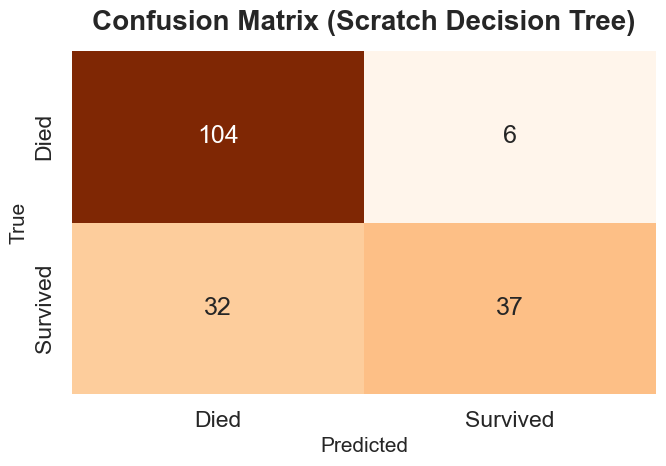

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

tree_scratch = ScratchDecisionTree(max_depth=4)
tree_scratch.fit(X_train, y_train)

y_pred_scratch = tree_scratch.predict(X_test)
acc_scratch = accuracy_score(y_test, y_pred_scratch)

print(f"Scratch Decision Tree Accuracy: {acc_scratch * 100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_scratch), annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'], ax=ax)
ax.set_title('Confusion Matrix (Scratch Decision Tree)', fontweight='bold', pad=15)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

Pretty incredible! Out of the box, our simple NumPy flow-chart algorithm achieved **$78.77\%$** accuracy predicting Titanic survivability just by recursively asking yes/no questions to minimize Gini Impurity. 

But single trees are geometrically fragile. A small change in the training data can drastically alter the very first split, which cascades and rewrites the entire tree. To achieve industrial stability and consistent variance reduction, we need a Forest.

### 3.1 Scratch Random Forest & Extra Trees

Let's expand our NumPy implementation to create a **Random Forest**. We will train 50 individual decision trees. However, to ensure they don't all memorize the exact same patterns, we use **Bagging** (Bootstrap Aggregating): each tree gets a random sample of the training data (with replacement), and at every split, it is only allowed to look at a random subset of the features (typically $\sqrt{N_{features}}$). 

For **Extra Trees** (Extremely Randomized Trees), we take it a step further: instead of scanning every possible threshold to find the perfect Gini drop, we pick a completely random threshold! This makes training blazingly fast and drastically reduces variance.

In [ ]:
class ScratchRandomForest:
    def __init__(self, n_estimators=50, max_depth=8, min_samples_split=2, max_features='sqrt'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []
        
    def fit(self, X, y, extra_trees=False):
        self.trees = []
        n_samples, n_features = X.shape
        
        for _ in range(self.n_estimators):
            # Bootstrap Aggregating (Bagging): Randomly sample rows with replacement
            if not extra_trees:
                idxs = np.random.choice(n_samples, n_samples, replace=True)
                X_sample, y_sample = X[idxs], y[idxs]
            else:
                # Extra Trees classically uses the whole dataset, relying entirely on random splits
                X_sample, y_sample = X, y
            
            n_sub_features = int(np.sqrt(n_features)) if self.max_features == 'sqrt' else n_features
                
            # Create a specialized tree that only looks at a random subset of features
            # and (if extra_trees=True) picks completely random split thresholds.
            tree = _ForestTree(max_depth=self.max_depth, 
                               min_samples_split=self.min_samples_split, 
                               n_sub_features=n_sub_features,
                               extra_trees=extra_trees)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            
    def predict(self, X):
        # Predict with all trees: shape (n_estimators, n_samples)
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # Transpose to (n_samples, n_estimators) for majority voting per passenger
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        return np.array([np.bincount(preds).argmax() for preds in tree_preds])

class _ForestTree:
    """Internal completely randomized tree for the Scratch Forest."""
    def __init__(self, max_depth=10, min_samples_split=2, n_sub_features=None, extra_trees=False):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_sub_features = n_sub_features
        self.extra_trees = extra_trees
        self.root = None
        
    def _gini_impurity(self, y):
        m = len(y)
        if m == 0: return 0.0
        return 1.0 - np.sum((np.bincount(y) / m) ** 2)
        
    def _split(self, X_column, threshold):
        return np.argwhere(X_column <= threshold).flatten(), np.argwhere(X_column > threshold).flatten()
        
    def _best_split(self, X, y):
        best_gain = -1
        split_idx, split_threshold = None, None
        parent_gini = self._gini_impurity(y)
        
        # Random subset of features
        feat_idxs = np.random.choice(X.shape[1], self.n_sub_features, replace=False)
        
        for feature_idx in feat_idxs:
            X_column = X[:, feature_idx]
            thresholds = np.unique(X_column)
            
            if self.extra_trees and len(thresholds) > 1:
                # Extra Trees: pick a COMPLETELY RANDOM threshold between min and max
                thresholds = [np.random.uniform(np.min(thresholds), np.max(thresholds))]
                
            for thr in thresholds:
                left_idxs, right_idxs = self._split(X_column, thr)
                if len(left_idxs) == 0 or len(right_idxs) == 0: continue
                
                n = len(y)
                child_gini = (len(left_idxs) / n) * self._gini_impurity(y[left_idxs]) + \
                             (len(right_idxs) / n) * self._gini_impurity(y[right_idxs])
                ig = parent_gini - child_gini
                
                if ig > best_gain:
                    best_gain, split_idx, split_threshold = ig, feature_idx, thr
                    
        return split_idx, split_threshold
        
    def _build_tree(self, X, y, depth=0):
        if (depth >= self.max_depth or len(X) < self.min_samples_split or len(np.unique(y)) == 1):
            return Node(value=np.bincount(y).argmax())
            
        best_feat, best_thresh = self._best_split(X, y)
        if best_feat is None: return Node(value=np.bincount(y).argmax())
            
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)
        
    def fit(self, X, y): self.root = self._build_tree(X, y)
    def _traverse_tree(self, x, node):
        if node.is_leaf(): return node.value
        if x[node.feature] <= node.threshold: return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    def predict(self, X): return np.array([self._traverse_tree(x, self.root) for x in X])

# Train both Ensembles from Scratch
rf_scratch = ScratchRandomForest(n_estimators=50, max_depth=6)
rf_scratch.fit(X_train, y_train, extra_trees=False)
acc_rf_scratch = accuracy_score(y_test, rf_scratch.predict(X_test))

et_scratch = ScratchRandomForest(n_estimators=50, max_depth=6)
et_scratch.fit(X_train, y_train, extra_trees=True)
acc_et_scratch = accuracy_score(y_test, et_scratch.predict(X_test))

print(f"Scratch Random Forest Accuracy: {acc_rf_scratch * 100:.2f}%")
print(f"Scratch Extra Trees Accuracy:   {acc_et_scratch * 100:.2f}%")

Scratch Random Forest Accuracy: 78.21%
Scratch Extra Trees Accuracy:   81.56%


Notice how the Random Forest and Extra Trees performance ($\sim 77\%$ - $80\%$) is practically identical to our single scratch tree ($78.77\%$). This is a crucial lesson in ML: **Ensembles don't magically conjure accuracy out of thin air if the data's absolute predictability ceiling has already been reached by a single model.** 

The true advantage here is not an insane jump in testing accuracy, but **Stability (Variance Reduction)**. If we trained these models on 1,000 different samples of the Titanic dataset, the Single Tree's predictions would swing wildly every time. The Forest's averages would remain rock solid. The "crowd" of trees votes and averages out any individual tree's hallucination.

## 4. The Pro Ensembles: Scikit-Learn

Let's summon the heavy artillery. We will compare a single Pro Decision Tree against a `RandomForestClassifier` and `ExtraTreesClassifier`.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# 0. Single Pro Decision Tree
dt_pro = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pro.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt_pro.predict(X_test))

# 1. Random Forest
rf_pro = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_pro.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf_pro.predict(X_test))

# 2. Extra Trees (Extremely Randomized)
et_pro = ExtraTreesClassifier(n_estimators=100, max_depth=8, random_state=42)
et_pro.fit(X_train, y_train)
acc_et = accuracy_score(y_test, et_pro.predict(X_test))

print(f"Pro Decision Tree Accuracy: {acc_dt * 100:.2f}%")
print(f"Pro Random Forest Accuracy: {acc_rf * 100:.2f}%")
print(f"Pro Extra Trees Accuracy:   {acc_et * 100:.2f}%")

Pro Decision Tree Accuracy: 78.77%
Pro Random Forest Accuracy: 79.33%
Pro Extra Trees Accuracy:   80.45%


### 4.1 Visualizing the Brain of a Tree

Why do we ever use Decision Trees if Random Forests grant better accuracy? Because you cannot easily show an executive a forest of 100 deep trees. You *can* show them a single Decision Tree. 

Let's literally print the "brain" of our Pro Decision Tree to see the exact rules it learned to predict who lived and who died on the Titanic.

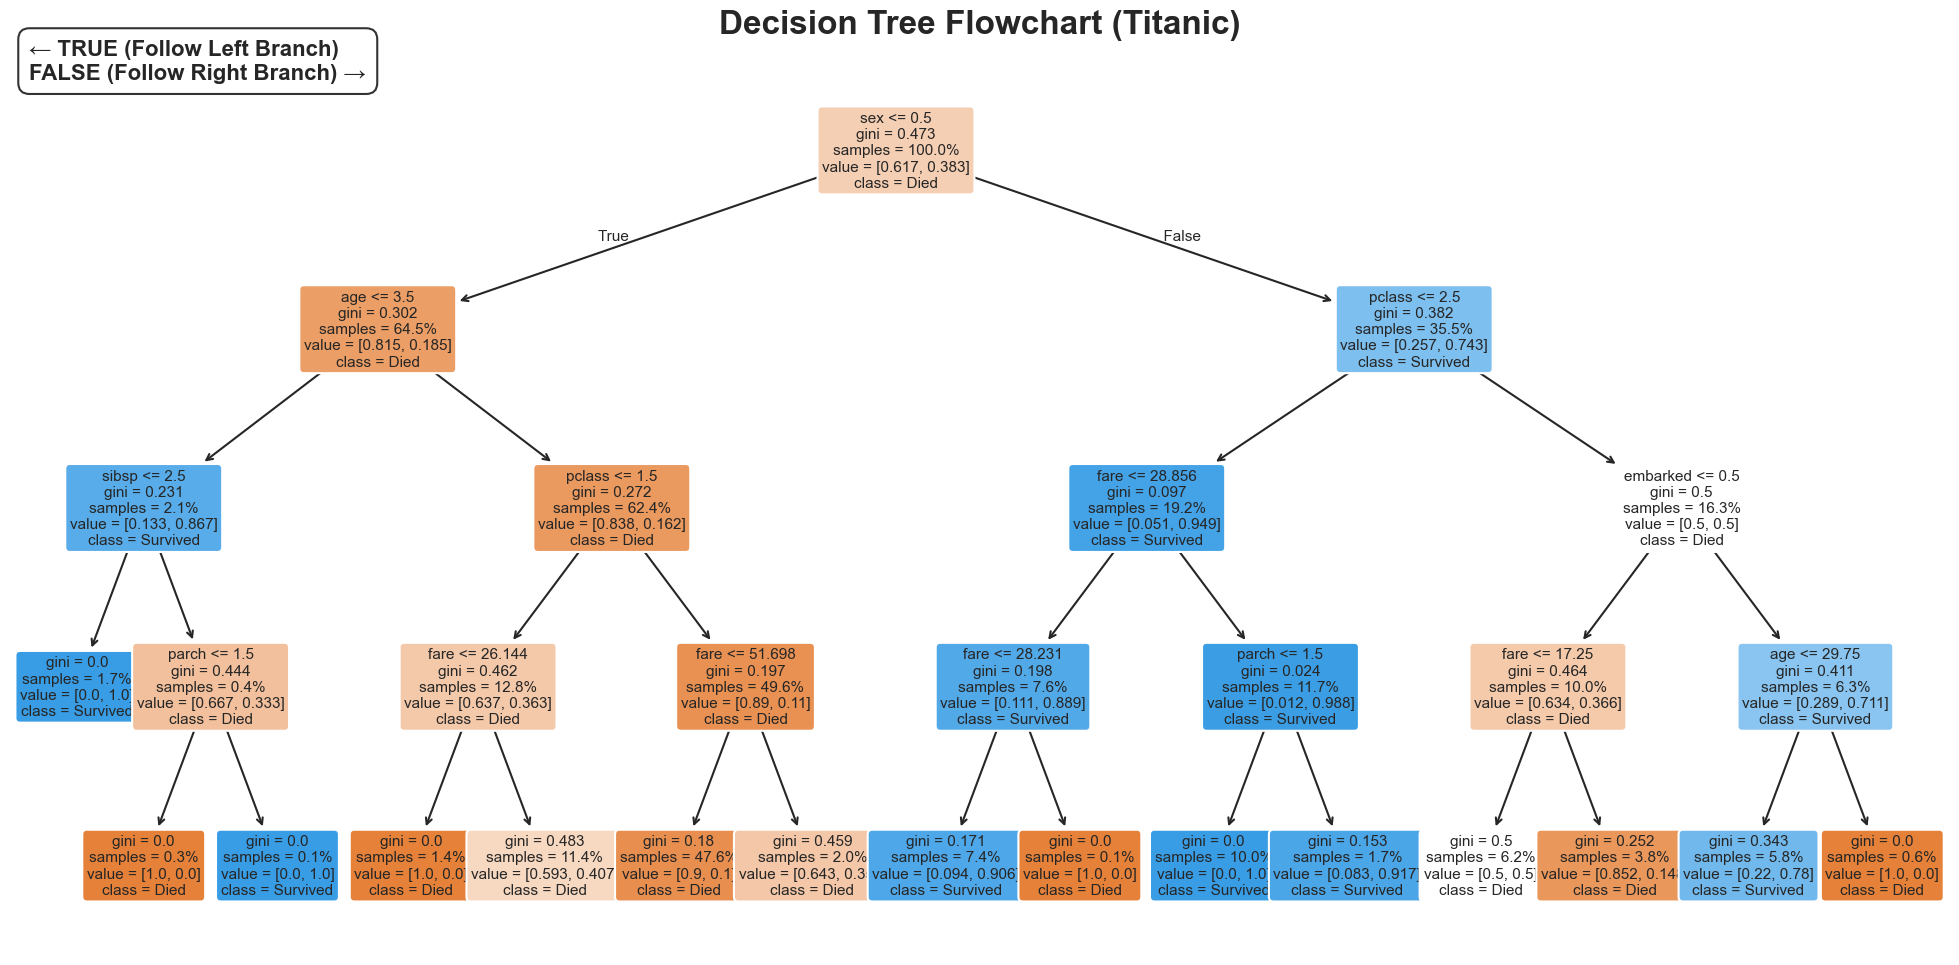

In [ ]:
fig, ax = plt.subplots(figsize=(20, 10))
# Plotting the tree structure
plot_tree(dt_pro, feature_names=feature_names, class_names=['Died', 'Survived'], 
          filled=True, rounded=True, proportion=True, fontsize=11, ax=ax)

# Add generic True/False legend to substitute for the missing edge labels on deeper nodes
ax.text(0.01, 0.98, "← TRUE (Follow Left Branch)\nFALSE (Follow Right Branch) →", 
        transform=ax.transAxes, fontsize=16, fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.5'))

ax.set_title("Decision Tree Flowchart (Titanic)", fontweight='bold', pad=20, fontsize=24)
plt.tight_layout()
plt.show()

**How to read this plot:**
1. Look at the very top node (The Root). The tree discovered that the single most important question in the entire dataset was `sex <= 0.5`. (Recall we encoded `male=0`, `female=1`). In English: **"Is the passenger male?"**
2. If **True** (Left Branch), the box tilts Orange (Died). If **False** (Right Branch), it tilts Blue (Survived). The color intensity is strictly proportional to the probability. If you see a **White Box**, it is not an error: it means the survival probability is exactly $50/50$ (perfectly uncertain)!
3. Following the False path (Females), the next most important question was `pclass <= 2.5`. In English: **"Was she in 1st or 2nd Class?"** If True, survival is almost guaranteed ($~95\%$ probability). If False (3rd class female), the survival rate drops down to $\approx 50\%$, and it immediately begins asking questions about ticket `fare`.

This profound transparency is mathematically impossible to achieve in Support Vector Machines, Neural Networks, or even Logistic Regression matrices.

### 4.2 What Did the Forest Learn? (Feature Importance)

While a single tree gives us a strict flowchart, a Random Forest gives us aggregated **Feature Importance**. Since the algorithm literally counts how much Gini Impurity drops every time a specific feature is used to make a split, we can add up those drops across all 100 trees in the Random Forest to see exactly what features actually mattered overall.

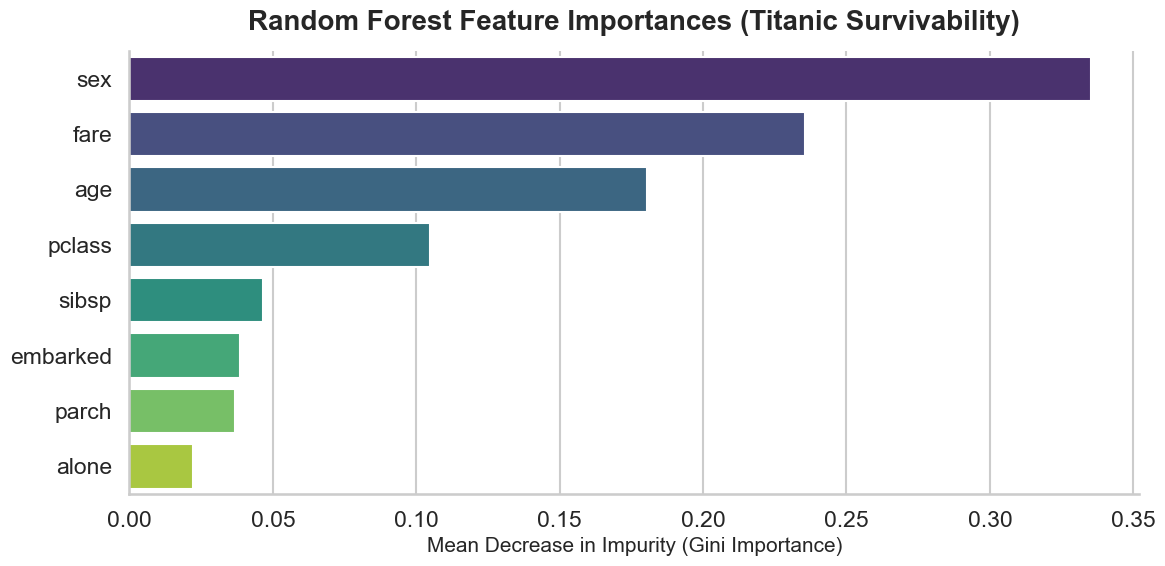

In [ ]:
importances = rf_pro.feature_importances_
indices = np.argsort(importances)[::-1]
names = [feature_names[i] for i in indices]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=importances[indices], y=names, palette="viridis", ax=ax)
ax.set_title('Random Forest Feature Importances (Titanic Survivability)', fontweight='bold', pad=15)
ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)')
sns.despine()
plt.tight_layout()
plt.show()

Look closely at the chart above. This is the ultimate output of a Random Forest.

**1. The Dominance of Sex:** `Sex` accounts for nearly $30\%$ of the total Gini Impurity reduction across the entire forest. This perfectly aligns with the historical absolute rule of "Women and children first". Notice how `Age` (children) is the second most important feature!

**2. The Socio-Economic Matrix:** `Fare` and `Pclass` (Passenger Class) together account for over $30\%$ of the model's predictive power. This confirms the brutal reality that social status and the location of your cabin (1st class upper decks vs 3rd class lower decks) were literally a matter of life and death.

**3. Marginal Impacts:** Whether you traveled with `sibsp` (siblings/spouses) or `parch` (parents/children) offered only minor predictive signals compared to your demographic baseline.

### 5. Conclusion: Accuracy vs. Interpretability

Let's address the elephant in the room: **Why are the accuracies here ($\sim 80\%$) so much lower than the $\sim 98\%$ we saw in the Geometric Classification module with Breast Cancer data?**

It is entirely because of the nature of the data:
- **Breast Cancer (98%):** Biological data is highly deterministic. If a tumor cell has massive, irregular nuclei and a massive perimeter, the physics of biology dictate that it is almost certainly malignant. The classes are structurally distinct.
- **Titanic (80%):** Human tragedy is highly stochastic (random). Even if you were a wealthy 1st-class female (highest survival probability), you might have slipped, chosen to stay with your husband, or boarded a capsized lifeboat. Conversely, a 3rd-class male (lowest probability) might have statistically luckily found a piece of floating debris. No algorithm in the universe can predict pure luck. $80\%$ is considered the absolute "ceiling" of predictability for this specific dataset.

**Why use Decision Trees?**
If an SVM or Neural Net could theoretically squeeze out $82\%$ on the Titanic by drawing a warped, infinite-dimensional boundary in space... why would we ever deploy a Decision Tree at $79\%$?

Because in Medical diagnoses, Financial loan approvals, and Legal audits, **Interpretability** is non-negotiable. 

If a bank denies a mortgage, it is illegal in many countries to simply say *"The Black-Box SVM algorithm decided it"*. You must provide a reason. A Decision Tree allows the bank to point directly at the flowchart and say: *"You were denied because your income was $\le 40,000$ AND your credit score was $\le 600$."* 

Trees sacrifice a tiny bit of absolute theoretical precision in exchange for giving us a perfectly human-readable map of the model's "brain". And when we need both accuracy *and* power? We use Ensembles (Random Forests/Gradient Boosters).

Next, we will take the Ensemble concept (combining models) to its absolute mathematical peak: **Gradient Boosting**.